# DBSCAN

In [8]:
pip install pandas numpy matplotlib scikit-learn

  Using cached pandas-3.0.6-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.0-cp314-cp314-win_amd64.whl.metadata (131 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


First 5 rows:
   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  
0   3.92     1065  
1   3.40     1050  
2   3.17     1185 

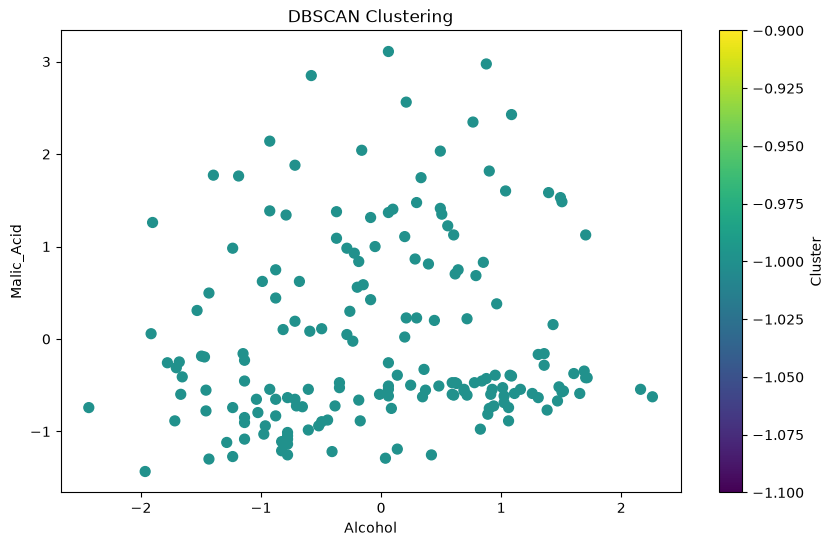


Silhouette Score cannot be calculated because
DBSCAN produced less than 2 clusters.

Final dataset:
   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   
5    14.20        1.76  2.45          15.2        112           3.27   
6    14.39        1.87  2.45          14.6         96           2.50   
7    14.06        2.15  2.61          17.6        121           2.60   
8    14.83        1.64  2.17          14.0         97           2.80   
9    13.86        1.35  2.27          16.0         98           2.98   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06              

In [19]:
# Step 1: Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score


# Step 2: Load the dataset

df = pd.read_csv(r"C:\Users\Harshitha\Desktop\FSDS\DBSCAN\DBSCAN\DBSACN_Dataset.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())


# Step 3: Select numerical columns

data = df.select_dtypes(include=np.number)

print("\nNumerical columns:")
print(data.columns)


# Step 4: Handle missing values

data = data.dropna()


# Step 5: Feature Scaling

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

print("\nScaled data:")
print(scaled_data[:5])


# Step 6: Apply DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = dbscan.fit_predict(scaled_data)


# Step 7: Add cluster labels to dataframe

df = df.loc[data.index].copy()

df["Cluster"] = labels

print("\nCluster labels:")
print(df["Cluster"].value_counts().sort_index())


# Step 8: Count number of clusters

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("\nNumber of clusters:", n_clusters)

if -1 in labels:
    print("Number of noise points:", list(labels).count(-1))
else:
    print("Number of noise points: 0")


# Step 9: Visualize the clusters

plt.figure(figsize=(10, 6))

plt.scatter(
    scaled_data[:, 0],
    scaled_data[:, 1],
    c=labels,
    cmap="viridis",
    s=50
)

plt.xlabel(data.columns[0])
plt.ylabel(data.columns[1])

plt.title("DBSCAN Clustering")

plt.colorbar(label="Cluster")

plt.show()


# Step 10: Silhouette Score

# Silhouette score cannot be calculated properly
# when DBSCAN produces only one cluster.

unique_labels = set(labels)

if len(unique_labels - {-1}) > 1:

    mask = labels != -1

    score = silhouette_score(
        scaled_data[mask],
        labels[mask]
    )

    print("\nSilhouette Score:", score)

else:
    print("\nSilhouette Score cannot be calculated because")
    print("DBSCAN produced less than 2 clusters.")


# Step 11: Display final dataset

print("\nFinal dataset:")
print(df.head(10))

In [10]:
df = pd.read_csv(r"C:\Users\HARSHITHA\Desktop\FSDS\DBSCAN\DBSCAN\DBSACN_Dataset.csv")

In [12]:
df = pd.read_csv(
    r"C:\Users\HARSHITHA\Desktop\FSDS\DBSCAN\DBSCAN\DBSACN_Dataset.csv"
)

In [8]:
import pandas as pd

df = pd.read_csv("DBSACN_Dataset.csv")

print(df.head())

   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  
0   3.92     1065  
1   3.40     1050  
2   3.17     1185  
3   3.45    

In [3]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import joblib

In [14]:
print(df.columns)

Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline'],
      dtype='str')


In [15]:
for column in df.columns:
    print(column)

Alcohol
Malic_Acid
Ash
Ash_Alcanity
Magnesium
Total_Phenols
Flavanoids
Nonflavanoid_Phenols
Proanthocyanins
Color_Intensity
Hue
OD280
Proline


In [20]:
# Select all numerical columns automatically
X = df.select_dtypes(include="number")

print("Selected columns:")
print(X.columns.tolist())

print(X.head())

Selected columns:
['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline', 'Cluster']
   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24     

In [21]:
X = X.fillna(X.median())

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
   1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
   1.01300893  0.        ]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502  0.56864766
   0.73362894 -0.82071924 -0.54472099 -0.29332133  0.40605066  1.1134493
   0.96524152  0.        ]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836  0.80899739
   1.21553297 -0.49840699  2.13596773  0.26901965  0.31830389  0.78858745
   1.39514818  0.        ]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845  2.49144552
   1.46652465 -0.98187536  1.03215473  1.18606801 -0.42754369  1.18407144
   2.33457383  0.        ]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515  0.80899739
   0.66335127  0.22679555  0.40140444 -0.31927553  0.36217728  0.44960118
  -0.03787401  0.        ]]


In [23]:
print(df.columns.tolist())

['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline', 'Cluster']


In [25]:
labels = dbscan.fit_predict(X_scaled)

In [26]:
from sklearn.metrics import silhouette_score

cluster_labels = set(labels) - {-1}

if len(cluster_labels) >= 2:
    score = silhouette_score(X_scaled, labels)
    print("Silhouette Score:", score)
else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score cannot be calculated.


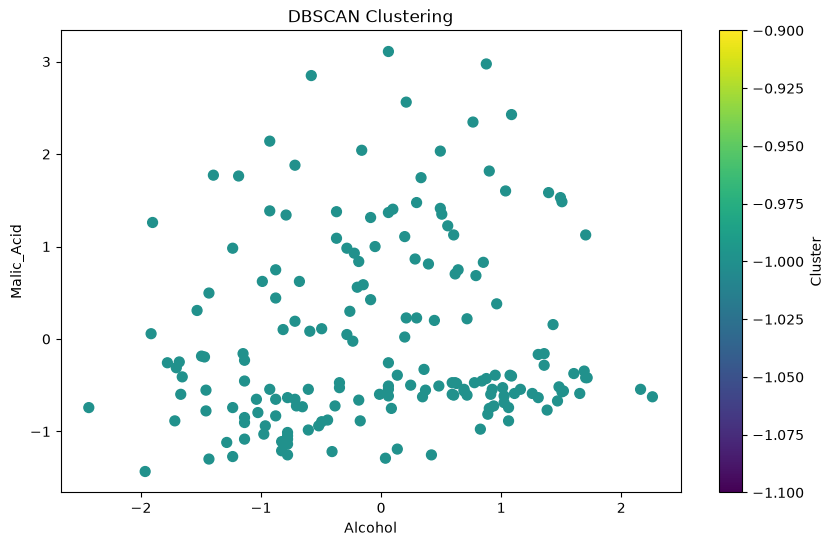

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    cmap="viridis",
    s=50
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("DBSCAN Clustering")

plt.colorbar(label="Cluster")

plt.show()

In [28]:
df.to_csv(
    "DBSCAN_Clustered_Dataset.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [30]:
import joblib

joblib.dump(
    dbscan,
    "dbscan_model.pkl"
)

print("DBSCAN model saved successfully!")

DBSCAN model saved successfully!


In [31]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!
